# Lab 2: KNN & Naive Bayes Classifiers
- Starter notebook

## Dependencies

In [1]:
import time
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Data

### Load data

In [2]:
dataset = load_breast_cancer()
print(dataset.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        worst/largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 0 is Mean Radi

In [3]:

feature_names = np.array(dataset.feature_names)
df = pd.DataFrame(dataset.data, columns=feature_names)
df['target'] = dataset.target
print(dataset.target_names)
df.head()

['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

target
1    357
0    212
Name: count, dtype: int64


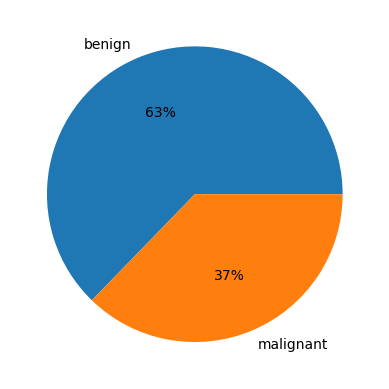

In [5]:
print(df['target'].value_counts())
plt.pie (df['target'].value_counts(), labels=['benign', 'malignant'], autopct='%1.0f%%')
plt.show()

### Feature correlations

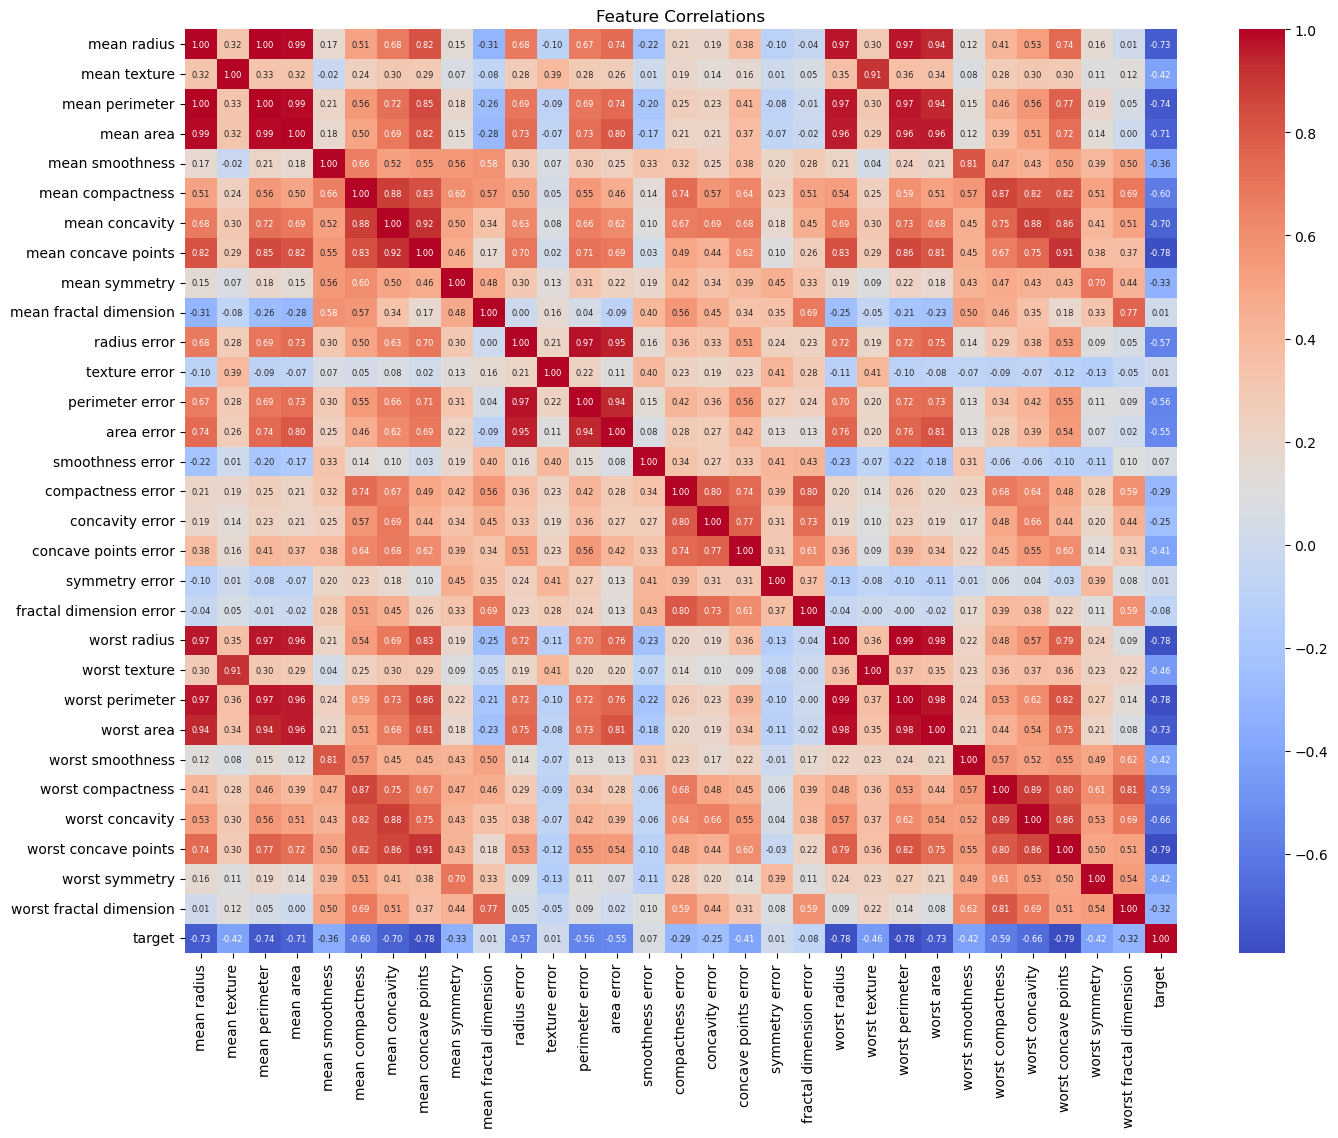

In [6]:
feature_correlation_matrix = df.corr()

# Visualize the correlations using a heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(feature_correlation_matrix, annot=True, fmt=".2f", annot_kws={'size': 6}, cmap='coolwarm')
plt.title("Feature Correlations")
plt.show()

## Feature Selection & Modeling

### Based on correlation with the target

In [7]:
# Find and list the top 5 features with the strongest correlation to the target
top_5_correlated_features = feature_correlation_matrix['target'].abs().sort_values(ascending=False).index[1:6].tolist()
top_5_correlated_features

['worst concave points',
 'worst perimeter',
 'mean concave points',
 'worst radius',
 'mean perimeter']

### Data Prepration

In [8]:
# split the data
random_state = 123
X, y = dataset.data, dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=random_state)

print(f'There are {X_train.shape[0]} samples in the training dataset')
print(f'There are {X_test.shape[0]} samples in the test dataset')

There are 455 samples in the training dataset
There are 114 samples in the test dataset


In [9]:
# scale the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### Sequential Feature Selection

#### KNN classifier

In [10]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier

# nearset neighbors 
knn = KNeighborsClassifier(n_neighbors=3)

# Forward selection
tic =time.time()
sfs = SequentialFeatureSelector(knn, n_features_to_select=5, direction='forward')
sfs.fit(X_train, y_train)
toc= time.time()
features = feature_names[sfs.get_support()]

print("KNN Classifier")
print(f"Top 5 features:{features}")
print(f"Forward selection took {toc-tic} seconds")

KNN Classifier
Top 5 features:['mean texture' 'mean concavity' 'worst radius' 'worst area'
 'worst smoothness']
Forward selection took 5.979956150054932 seconds


In [11]:
# train the knn model
knn.fit(sfs.transform(X_train), y_train)

KNeighborsClassifier(n_neighbors=3)

In [12]:
print(f"Train accuracy: {knn.score(sfs.transform(X_train), y_train):.3f}")
print(f"Test accuracy: {knn.score(sfs.transform(X_test), y_test):.3f}")

Train accuracy: 0.976
Test accuracy: 0.956


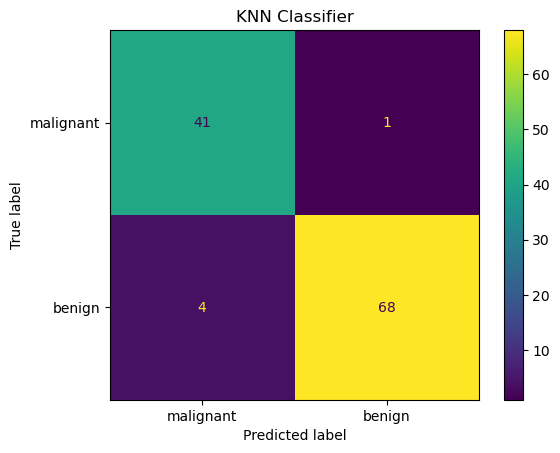

In [13]:
# confusion matrix
yhat = knn.predict(sfs.transform(X_test))
cm = confusion_matrix(y_test, yhat)
cm_display = ConfusionMatrixDisplay(cm, display_labels=dataset.target_names).plot()
plt.title('KNN Classifier')
plt.show()

#### Naive Bayes classifier

In [14]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

# Forward selection
tic =time.time()
sfs = SequentialFeatureSelector(gnb, n_features_to_select=5, direction='forward')
sfs.fit(X_train, y_train)
toc= time.time()
features = feature_names[sfs.get_support()]
print("Naive Bayes Classifier")
print(f"Top 5 features with SFS forward:{features}")
print(f"Forward selection took {toc-tic} seconds")

Naive Bayes Classifier
Top 5 features with SFS forward:['mean texture' 'concavity error' 'worst radius' 'worst texture'
 'worst concave points']
Forward selection took 1.3661739826202393 seconds


In [15]:
# train the model
gnb.fit(sfs.transform(X_train), y_train)

GaussianNB()

In [16]:
print(f"Train accuracy: {gnb.score(sfs.transform(X_train), y_train):.3f}")
print(f"Test accuracy: {gnb.score(sfs.transform(X_test), y_test):.3f}")

Train accuracy: 0.971
Test accuracy: 0.974


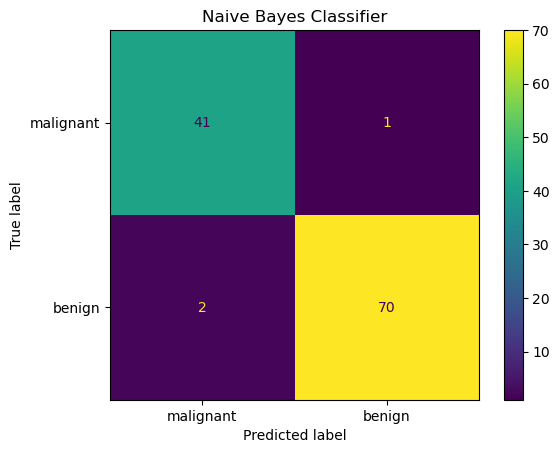

In [17]:
# confusion matrix
yhat = gnb.predict(sfs.transform(X_test))
cm = confusion_matrix(y_test, yhat)
cm_display = ConfusionMatrixDisplay(cm, display_labels=dataset.target_names).plot()
plt.title('Naive Bayes Classifier')
plt.show()